## Full Run — India Macroeconomic Prediction System

End-to-end pipeline:
1. Load clustered GDP data
2. User selects target country
3. Granger Causality Test — filter predictive countries
4. User provides optional stress projection for one country
5. User sets prediction horizon
6. Prophet forecasts all other cluster countries
7. VAR step-wise prediction — one year at a time
8. Plot final results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

**Helper — Invert differencing to restore original scale**

In [2]:
def invert_transformation(df_train, df_forecast, second_diff=True):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc   = df_forecast.copy()
    columns = df_train.columns
    for col in columns:
        if second_diff:
            df_fc[str(col) + '_1d'] = (
                (df_train[col].iloc[-1] - df_train[col].iloc[-2])
                + df_fc[str(col)].cumsum()
            )
        df_fc[str(col) + '_forecast'] = (
            df_train[col].iloc[-1] + df_fc[str(col) + '_1d'].cumsum()
        )
    return df_fc

**Load clustered GDP data**

In [3]:
gdp_df_imf = pd.read_excel('gdp_imf_clustered.xlsx')
gdp_df_imf.head(2)

,COUNTRY,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2018,2019,2020,2021,2022,2023,2024,2025,2026,Cluster
0,ASEAN-5,5.627,2.728,4.870,5.516,6.157,5.281,5.660,6.378,4.939,...,4.951,4.209,-4.416,4.073,5.516,4.070,4.635,4.165,4.092,0
1,Advanced Economies,4.158,1.577,1.639,2.025,3.251,2.833,3.085,2.755,0.314,...,2.286,1.870,-3.928,6.033,2.980,1.727,1.827,1.607,1.634,0


**User Inputs**

In [4]:
print('List of countries:\n', gdp_df_imf['COUNTRY'].values.tolist())
target_country = input('\nWhich country do you want to predict GDP for?\n ').title()

List of countries:
 ['ASEAN-5', 'Advanced Economies', 'Afghanistan, Islamic Republic of', 'Albania', 'Algeria', 'Andorra, Principality of', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia, Republic of', 'Aruba, Kingdom of the Netherlands', 'Australia', 'Austria', 'Azerbaijan, Republic of', 'Bahamas, The', 'Bahrain, Kingdom of', 'Bangladesh', 'Barbados', 'Belarus, Republic of', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', "China, People's Republic of", 'Colombia', 'Comoros, Union of the', 'Congo, Democratic Republic of the', 'Congo, Republic of', 'Costa Rica', 'Croatia, Republic of', 'Cyprus', 'Czech Republic', "Côte d'Ivoire", 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt, Arab Republic of', 'El Salvador', 'Emerging Market and Developing Economies


Which country do you want to predict GDP for?
  India


In [5]:
target_cluster           = gdp_df_imf[gdp_df_imf['COUNTRY'] == target_country]['Cluster'].values[0]
target_df                = gdp_df_imf[gdp_df_imf['Cluster'] == target_cluster]
target_cluster_countries = target_df['COUNTRY'].tolist()

print(f'{target_country} shares cluster {target_cluster} with:\n{target_cluster_countries}')

India shares cluster 0 with:
['ASEAN-5', 'Advanced Economies', 'Afghanistan, Islamic Republic of', 'Albania', 'Algeria', 'Andorra, Principality of', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia, Republic of', 'Aruba, Kingdom of the Netherlands', 'Australia', 'Austria', 'Azerbaijan, Republic of', 'Bahamas, The', 'Bahrain, Kingdom of', 'Bangladesh', 'Barbados', 'Belarus, Republic of', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', "China, People's Republic of", 'Colombia', 'Comoros, Union of the', 'Congo, Democratic Republic of the', 'Congo, Republic of', 'Costa Rica', 'Croatia, Republic of', 'Cyprus', 'Czech Republic', "Côte d'Ivoire", 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt, Arab Republic of', 'El Salvador', 'Emerging Market and Developing 

**Preprocess — Transpose to (year × country)**

In [6]:
processed_df = target_df.drop(columns='Cluster').T.reset_index()
processed_df.columns = processed_df.loc[0]
processed_df = processed_df.iloc[1:, :]
processed_df.rename(columns={'COUNTRY': 'year'}, inplace=True)
processed_df['year'] = pd.to_datetime(processed_df['year'], format='%Y')

for col in processed_df.columns[1:]:
    processed_df[col] = pd.to_numeric(processed_df[col], errors='coerce')

processed_df.head()

,year,ASEAN-5,Advanced Economies,"Afghanistan, Islamic Republic of",Albania,Algeria,"Andorra, Principality of",Angola,Antigua and Barbuda,Argentina,...,Uruguay,"Uzbekistan, Republic of",Vanuatu,"Venezuela, República Bolivariana de",Vietnam,West Bank and Gaza,World,"Yemen, Republic of",Zambia,Zimbabwe
1,2000-01-01,5.627,4.158,0.000,6.946,3.8,0.000,3.055,6.204,-0.789,...,-1.930,3.8,5.925,3.687,6.787,-8.556,4.781,6.182,3.897,-4.231
2,2001-01-01,2.728,1.577,0.000,8.293,3.0,8.119,4.206,-4.548,-4.409,...,-3.844,4.2,-3.398,3.394,6.895,-9.311,2.495,3.804,5.317,-0.454
3,2002-01-01,4.870,1.639,0.000,4.537,5.4,4.546,13.666,1.027,-10.894,...,-7.732,4.0,-5.198,-8.856,7.080,-12.488,2.831,3.935,4.506,-7.704
4,2003-01-01,5.516,2.025,8.692,5.529,6.5,8.694,3.490,6.077,8.955,...,0.805,4.2,4.288,-7.755,7.341,14.016,3.813,3.747,6.945,-16.224
5,2004-01-01,6.157,3.251,0.671,5.515,4.5,8.136,11.420,5.767,8.911,...,5.004,7.4,3.987,18.287,7.789,21.924,5.274,3.973,7.032,-6.270


**Granger Causality Test — filter countries with predictive power**

In [7]:
maxlag    = 4
threshold = 0.05
countries = []
c_dic     = {}

for country in processed_df.iloc[:, 1:]:
    list_ps   = []
    list_lags = []

    if country == target_country:
        continue

    testing_df = processed_df[[target_country, country]].dropna()
    try:
        stats_test = grangercausalitytests(testing_df, maxlag=maxlag, verbose=False)
        for c in range(maxlag):
            p_value = round(stats_test[c+1][0]['ssr_ftest'][1], 4)
            if p_value < threshold:
                list_ps.append(p_value)
                list_lags.append(c+1)
                countries.append(country)
    except Exception as e:
        print(f'Skipping {country}: {e}')

    c_dic[country] = list_lags
    print(f'{country} — significant lags: {list_lags}')

important_countries = list(dict.fromkeys(countries))
print(f'\nCountries with significant Granger causality toward {target_country}:')
for c in important_countries:
    print(f'  ✅ {c}')

ASEAN-5 — significant lags: []
Advanced Economies — significant lags: []
Afghanistan, Islamic Republic of — significant lags: []
Albania — significant lags: []
Algeria — significant lags: []
Andorra, Principality of — significant lags: []
Angola — significant lags: []
Antigua and Barbuda — significant lags: []
Argentina — significant lags: []
Armenia, Republic of — significant lags: []
Aruba, Kingdom of the Netherlands — significant lags: []
Australia — significant lags: []
Austria — significant lags: []
Azerbaijan, Republic of — significant lags: []
Bahamas, The — significant lags: []
Bahrain, Kingdom of — significant lags: []
Bangladesh — significant lags: [1, 3]
Barbados — significant lags: []
Belarus, Republic of — significant lags: []
Belgium — significant lags: []
Belize — significant lags: []
Benin — significant lags: []
Bhutan — significant lags: []
Bolivia — significant lags: []
Bosnia and Herzegovina — significant lags: []
Botswana — significant lags: []
Brazil — significant 

**User Input — Optional stress projection for one country**

In [8]:
user_choice = input('\nDo you have a stress projection for one country? yes or no\n ').lower()

countries_to_drop = [target_country]

if user_choice == 'yes':
    user_input_country = input('Which country?\n ').title()
    if user_input_country not in target_cluster_countries:
        print(f'{user_input_country} not found in cluster')
        user_choice = 'no'
    else:
        countries_to_drop.append(user_input_country)
else:
    print('No projection provided — Prophet will forecast all cluster countries')

countries_to_predict = [c for c in target_cluster_countries if c not in countries_to_drop]
print(f'\nCountries Prophet will forecast: {countries_to_predict}')


Do you have a stress projection for one country? yes or no
  no


No projection provided — Prophet will forecast all cluster countries

Countries Prophet will forecast: ['ASEAN-5', 'Advanced Economies', 'Afghanistan, Islamic Republic of', 'Albania', 'Algeria', 'Andorra, Principality of', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia, Republic of', 'Aruba, Kingdom of the Netherlands', 'Australia', 'Austria', 'Azerbaijan, Republic of', 'Bahamas, The', 'Bahrain, Kingdom of', 'Bangladesh', 'Barbados', 'Belarus, Republic of', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', "China, People's Republic of", 'Colombia', 'Comoros, Union of the', 'Congo, Democratic Republic of the', 'Congo, Republic of', 'Costa Rica', 'Croatia, Republic of', 'Cyprus', 'Czech Republic', "Côte d'Ivoire", 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 

In [10]:
prediction_horizon = int(input('\nHow many years ahead to predict?\n '))
print(f'Prediction horizon: {prediction_horizon} years')


How many years ahead to predict?
  5


Prediction horizon: 5 years


**Prophet — Forecast all cluster countries except target**

In [11]:
prediction_df = pd.DataFrame()

for country in countries_to_predict:
    df         = processed_df[['year', country]].dropna().copy()
    df.columns = ['ds', 'y']

    m      = Prophet(seasonality_mode='multiplicative')
    m.fit(df)

    future   = m.make_future_dataframe(periods=prediction_horizon, freq='YE')
    forecast = m.predict(future)[['ds', 'yhat']].set_index('ds')
    forecast.columns = [country]

    prediction_df = pd.concat([prediction_df, forecast], axis=1)
    print(f'✅ Prophet done: {country}')

prediction_df = prediction_df.reset_index().rename(columns={'index': 'ds'})
prediction_df.tail()

13:20:46 - cmdstanpy - INFO - Chain [1] start processing
13:20:46 - cmdstanpy - INFO - Chain [1] done processing
13:20:46 - cmdstanpy - INFO - Chain [1] start processing
13:20:46 - cmdstanpy - INFO - Chain [1] done processing
13:20:46 - cmdstanpy - INFO - Chain [1] start processing
13:20:46 - cmdstanpy - INFO - Chain [1] done processing
13:20:46 - cmdstanpy - INFO - Chain [1] start processing
13:20:46 - cmdstanpy - INFO - Chain [1] done processing
13:20:46 - cmdstanpy - INFO - Chain [1] start processing


✅ Prophet done: ASEAN-5
✅ Prophet done: Advanced Economies
✅ Prophet done: Afghanistan, Islamic Republic of
✅ Prophet done: Albania


13:20:46 - cmdstanpy - INFO - Chain [1] done processing
13:20:46 - cmdstanpy - INFO - Chain [1] start processing
13:20:46 - cmdstanpy - INFO - Chain [1] done processing
13:20:46 - cmdstanpy - INFO - Chain [1] start processing
13:20:46 - cmdstanpy - INFO - Chain [1] done processing
13:20:46 - cmdstanpy - INFO - Chain [1] start processing


✅ Prophet done: Algeria
✅ Prophet done: Andorra, Principality of
✅ Prophet done: Angola


13:20:47 - cmdstanpy - INFO - Chain [1] done processing
13:20:47 - cmdstanpy - INFO - Chain [1] start processing
13:20:47 - cmdstanpy - INFO - Chain [1] done processing
13:20:47 - cmdstanpy - INFO - Chain [1] start processing
13:20:47 - cmdstanpy - INFO - Chain [1] done processing
13:20:47 - cmdstanpy - INFO - Chain [1] start processing


...

13:21:02 - cmdstanpy - INFO - Chain [1] start processing
13:21:02 - cmdstanpy - INFO - Chain [1] done processing
13:21:02 - cmdstanpy - INFO - Chain [1] start processing
13:21:02 - cmdstanpy - INFO - Chain [1] done processing
13:21:03 - cmdstanpy - INFO - Chain [1] start processing
13:21:03 - cmdstanpy - INFO - Chain [1] done processing
13:21:03 - cmdstanpy - INFO - Chain [1] start processing
13:21:03 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet done: West Bank and Gaza
✅ Prophet done: World
✅ Prophet done: Yemen, Republic of
✅ Prophet done: Zambia


13:21:03 - cmdstanpy - INFO - Chain [1] start processing
13:21:03 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet done: Zimbabwe


,ds,ASEAN-5,Advanced Economies,"Afghanistan, Islamic Republic of",Albania,Algeria,"Andorra, Principality of",Angola,Antigua and Barbuda,Argentina,...,Uruguay,"Uzbekistan, Republic of",Vanuatu,"Venezuela, República Bolivariana de",Vietnam,West Bank and Gaza,World,"Yemen, Republic of",Zambia,Zimbabwe
27,2026-12-31,3.448719,0.672336,-0.233465,1.783002,1.347447,-1.791328,-0.498830,-16.120747,-21.606086,...,-0.279026,5.825746,2.580043,-27.136647,5.044047,-32.680412,2.285619,-15.574884,2.256095,0.516648
28,2027-12-31,3.325645,0.358572,0.144085,1.597679,1.170482,-2.441785,-0.795530,-20.991634,-27.933771,...,-1.014118,5.673589,2.703040,-32.914062,4.686875,-41.696804,2.044988,-18.861256,1.836974,-0.940391
29,2028-12-31,3.393976,1.219337,-1.322975,1.810183,1.435738,-0.366463,-1.223922,-10.800343,-13.268585,...,1.211468,6.133456,1.833814,-21.121824,5.383011,-22.883342,2.585606,-12.378094,2.810706,3.730254
30,2029-12-31,3.290431,0.951454,-0.941330,1.603560,1.263227,-1.019597,-1.521823,-15.697940,-19.664157,...,0.467024,5.994691,1.962390,-26.902433,5.148023,-31.917810,2.385991,-15.670652,2.392758,2.260772
31,2030-12-31,3.179010,0.662569,-0.419802,1.418577,1.099357,-1.642600,-1.797508,-21.106548,-26.585938,...,-0.298982,5.848828,2.061349,-33.132550,4.856683,-41.829442,2.170731,-19.224849,1.995080,0.634974


In [12]:
prediction_df.head()

,ds,ASEAN-5,Advanced Economies,"Afghanistan, Islamic Republic of",Albania,Algeria,"Andorra, Principality of",Angola,Antigua and Barbuda,Argentina,...,Uruguay,"Uzbekistan, Republic of",Vanuatu,"Venezuela, República Bolivariana de",Vietnam,West Bank and Gaza,World,"Yemen, Republic of",Zambia,Zimbabwe
0,2000-01-01,5.437171,1.615173,5.715955,5.116373,3.800431,0.503587,9.071269,6.479981,3.892764,...,0.982384,6.091373,4.158450,7.353640,7.018762,12.248612,3.755094,5.137804,5.957699,-2.602012
1,2001-01-01,5.395016,2.248035,9.949644,6.095551,4.430535,3.741189,9.435776,-4.258151,-3.853671,...,2.193379,6.456892,2.142235,1.263345,6.971224,-4.127735,4.150874,1.111916,7.742172,-4.410526
2,2002-01-01,5.331295,2.055173,8.050262,5.581921,4.112998,2.627236,8.825564,-0.774057,-1.240994,...,1.860721,6.350778,2.727780,2.627901,6.995009,0.904755,3.997845,2.021678,7.001837,-3.281813
3,2003-01-01,5.252373,1.836921,6.291787,5.109454,3.798734,1.538631,8.228686,2.192614,0.803315,...,1.502150,6.237164,3.281782,3.557244,6.940785,5.082031,3.818610,2.674607,6.277683,-2.314728
4,2004-01-01,5.158860,1.593805,4.676042,4.676902,3.488429,0.476791,7.646175,4.637065,2.278036,...,1.118219,6.116171,3.803742,4.046585,6.810308,8.393790,3.614158,3.068073,5.570660,-1.510185


In [12]:
if user_choice == 'yes':
    all_numbers = []
    for i in range(prediction_horizon):
        inp = float(input(f'Enter GDP growth projection year {i+1} for {user_input_country}: '))
        all_numbers.append(inp)

    user_proj_series  = pd.Series(all_numbers)
    historical_series = processed_df[user_input_country].dropna().reset_index(drop=True)
    user_full_projection = pd.concat([historical_series, user_proj_series]).reset_index(drop=True)
    print(f'\n{user_input_country} full series (last 5):')
    print(user_full_projection.tail())

**VAR Step-wise Prediction**

In [13]:
# Filter BEFORE differencing — only target + Granger countries
var_countries = [target_country] + important_countries
var_countries = [c for c in var_countries if c in processed_df.columns]

df_p = processed_df.copy().set_index('year')[var_countries]

print(f'VAR countries: {var_countries}')
print(f'Shape: {df_p.shape}')

# 1st difference only
df_differenced = df_p.diff().dropna()

nobs        = len(df_differenced)
n_countries = df_differenced.shape[1]

max_estimable = int((nobs - n_countries) / n_countries)
maxlags       = max(1, min(2, max_estimable))

print(f'Observations     : {nobs}')
print(f'Countries        : {n_countries}')
print(f'Max estimable lag: {max_estimable}')
print(f'Using maxlags    : {maxlags}')

model        = VAR(df_differenced)
lag_order    = model.select_order(maxlags=maxlags)
best_lag     = max(1, lag_order.aic)
model_fitted = model.fit(best_lag)

print(f'Selected lag order: {best_lag}')
print(model_fitted.summary())

VAR countries: ['India', 'Philippines']
Shape: (27, 2)
Observations     : 26
Countries        : 2
Max estimable lag: 12
Using maxlags    : 2
Selected lag order: 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 04, Mar, 2026
Time:                     05:37:25
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    4.53815
Nobs:                     25.0000    HQIC:                   4.32675
Log likelihood:          -118.017    FPE:                    69.9614
AIC:                      4.24562    Det(Omega_mle):         55.7728
--------------------------------------------------------------------
Results for equation India
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.065352         0.708021         

/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [14]:
all_forecasts = []
df_working    = df_p.copy()

# Use only important_countries + target to keep equations manageable
var_countries = [target_country] + important_countries
# Filter to only those that exist in df_working
var_countries = [c for c in var_countries if c in df_working.columns]
df_working    = df_working[var_countries]

print(f'VAR using {len(var_countries)} countries: {var_countries}')

for step in range(prediction_horizon):
    print(f'\n--- Step {step + 1} of {prediction_horizon} ---')

    # 1st difference only
    df_diff = df_working.diff().dropna()

    try:
        var_model  = VAR(df_diff)
        var_fitted = var_model.fit(1)
    except Exception as e:
        print(f'VAR failed at step {step+1}: {e}')
        break

    fc    = var_fitted.forecast(y=df_diff.values, steps=1)
    df_fc = pd.DataFrame(fc, columns=df_working.columns)

    # Invert 1st diff — last known value + forecast delta
    fc_val = df_working[target_country].iloc[-1] + df_fc[target_country].values[0]
    all_forecasts.append(fc_val)
    print(f'{target_country} GDP growth forecast — year {step+1}: {fc_val:.4f}')

    # Build next step — target VAR forecast + Prophet slice + user projection
    next_target   = pd.Series([fc_val], name=target_country)
    target_series = pd.concat(
        [df_working[target_country].reset_index(drop=True), next_target]
    ).reset_index(drop=True)

    # Prophet slice for countries in var_countries (excluding target)
    prophet_countries = [c for c in var_countries if c != target_country
                         and c in prediction_df.columns]
    fb_slice = prediction_df[prophet_countries].iloc[:len(df_working) + 1, :].reset_index(drop=True)

    if user_choice == 'yes' and user_input_country in var_countries:
        user_slice = pd.Series(
            user_full_projection.iloc[:len(df_working) + 1].values,
            name=user_input_country
        )
        next_df = pd.concat([target_series, fb_slice, user_slice], axis=1)
    else:
        next_df = pd.concat([target_series, fb_slice], axis=1)

    for col in next_df.columns:
        next_df[col] = pd.to_numeric(next_df[col], errors='coerce')

    next_df.index = list(df_working.index) + [
        df_working.index[-1] + pd.DateOffset(years=1)
    ]
    df_working = next_df

VAR using 2 countries: ['India', 'Philippines']

--- Step 1 of 5 ---
India GDP growth forecast — year 1: 5.9874

--- Step 2 of 5 ---
India GDP growth forecast — year 2: 4.0752

--- Step 3 of 5 ---
India GDP growth forecast — year 3: 4.6760

--- Step 4 of 5 ---
India GDP growth forecast — year 4: 5.6858

--- Step 5 of 5 ---
India GDP growth forecast — year 5: 4.8125


/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/hardikgogia/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWar

**Results**

In [15]:
historical_vals = processed_df.set_index('year')[target_country].dropna()

forecast_years = pd.date_range(
    start=historical_vals.index[-1] + pd.DateOffset(years=1),
    periods=prediction_horizon,
    freq='YE'
)

forecast_series = pd.Series(all_forecasts, index=forecast_years)

print(f'\n{target_country} — GDP Growth Forecast:')
print(forecast_series.round(4).to_string())


India — GDP Growth Forecast:
2027-12-31    5.9874
2028-12-31    4.0752
2029-12-31    4.6760
2030-12-31    5.6858
2031-12-31    4.8125
Freq: YE-DEC


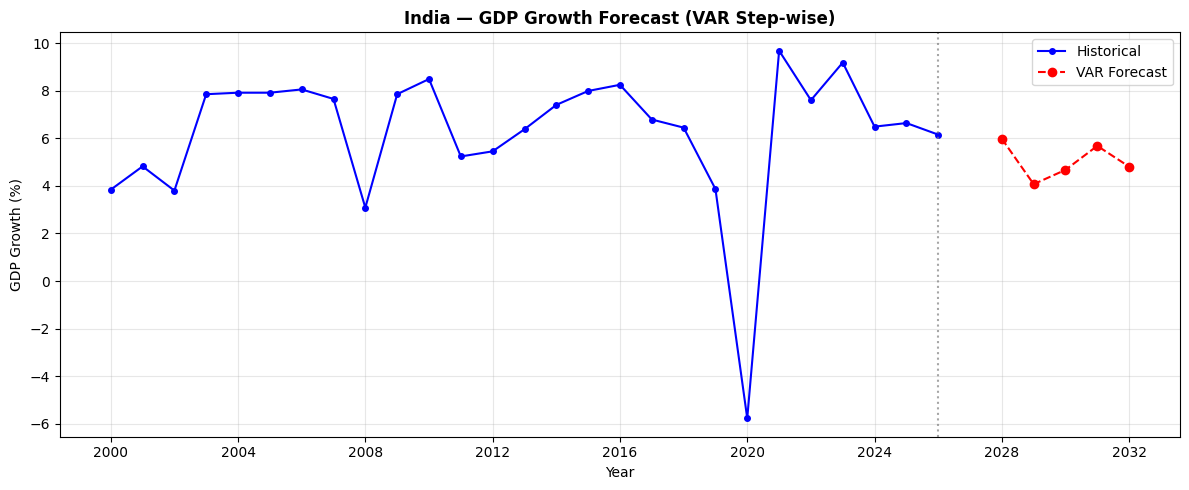

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(historical_vals.index, historical_vals.values, 'b-o', markersize=4, label='Historical')
plt.plot(forecast_series.index, forecast_series.values, 'r--o', markersize=6, label='VAR Forecast')
plt.axvline(historical_vals.index[-1], color='grey', linestyle=':', alpha=0.7)
plt.title(f'{target_country} — GDP Growth Forecast (VAR Step-wise)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('final_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# End